✅ Grafik Dinamis berhasil dibuat! Disimpan di: ../output_json/grafik_konvergensi_final.png


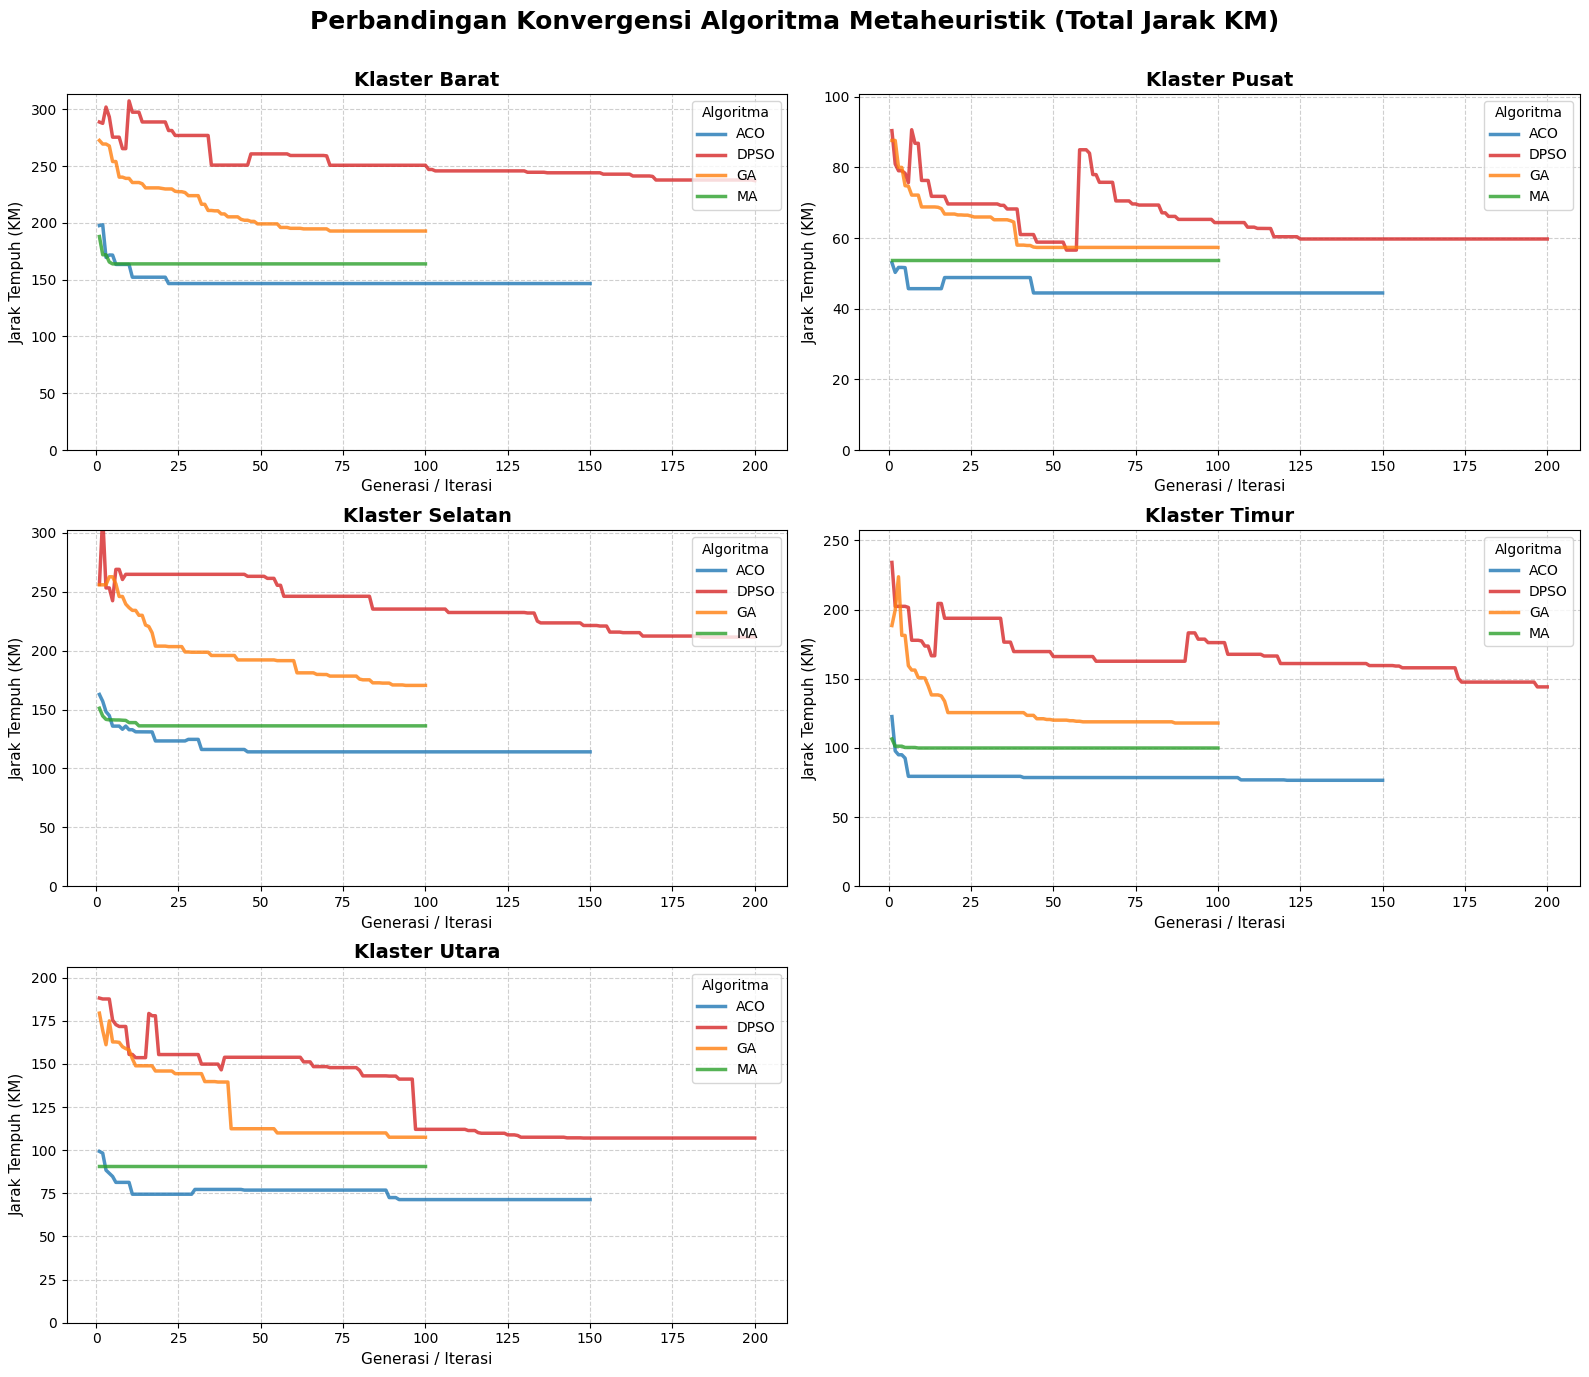

In [2]:
import matplotlib.pyplot as plt
import json
import os

# 1. Setup Path & Nama File
path_json = '../output_json'
file_mapping = {
    'ACO': 'rute_aco.json',
    'DPSO': 'rute_dpso.json',
    'GA': 'rute_ga.json',
    'MA': 'rute_ma.json'
}

# 2. Load Semua Data JSON
data_all = {}
for algo, filename in file_mapping.items():
    filepath = os.path.join(path_json, filename)
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            data_all[algo] = json.load(f)
    else:
        print(f"⚠️ Peringatan: {filename} belum ada di folder!")

# 3. Setup Kanvas Grafik (3 Baris x 2 Kolom)
klaster_list = ['Barat', 'Pusat', 'Selatan', 'Timur', 'Utara']
warna_algo = {'ACO': '#1f77b4', 'DPSO': '#d62728', 'GA': '#ff7f0e', 'MA': '#2ca02c'} 

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Perbandingan Konvergensi Algoritma Metaheuristik (Total Jarak KM)', fontsize=18, fontweight='bold', y=0.98)
axes = axes.flatten()

# 4. Plotting untuk setiap Klaster
for idx, klaster in enumerate(klaster_list):
    ax = axes[idx]
    
    max_normal = 0 # Variabel untuk mengukur atap grafik
    
    for algo, data in data_all.items():
        klaster_key = klaster if klaster in data['hasil_per_klaster'] else klaster.capitalize()
        
        if klaster_key in data['hasil_per_klaster']:
            riwayat = data['hasil_per_klaster'][klaster_key].get('riwayat_konvergensi')
            if riwayat and isinstance(riwayat, list):
                
                # 🔥 REVISI: POTONG DPSO MAKSIMAL 200 ITERASI 🔥
                if algo == 'DPSO':
                    riwayat = riwayat[:200]
                
                # Gambar semua garis termasuk DPSO yang sudah dipotong
                ax.plot(range(1, len(riwayat) + 1), riwayat, label=algo, color=warna_algo.get(algo), linewidth=2.5, alpha=0.8)
                
                # 🔥 MENGUKUR ATAP GRAFIK: Abaikan lonjakan aneh DPSO 🔥
                if algo != 'DPSO':
                    tertinggi_di_algo_ini = max(riwayat)
                    if tertinggi_di_algo_ini > max_normal:
                        max_normal = tertinggi_di_algo_ini
    
    # Set batas Y secara dinamis per klaster (Batas tertinggi algoritma normal + 15% ruang kosong)
    if max_normal > 0:
        ax.set_ylim(bottom=0, top=max_normal * 1.15)
        
    # Percantik tiap grafik
    ax.set_title(f'Klaster {klaster}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Generasi / Iterasi', fontsize=11)
    ax.set_ylabel('Jarak Tempuh (KM)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title='Algoritma', loc='upper right')

# Sembunyikan subplot ke-6 yang kosong
axes[-1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Simpan grafiknya jadi gambar kualitas tinggi
file_gambar = '../output_json/grafik_konvergensi_final.png'
plt.savefig(file_gambar, dpi=300, bbox_inches='tight')
print(f"✅ Grafik Dinamis berhasil dibuat! Disimpan di: {file_gambar}")

plt.show()